# Data Science Project
## Real-time Election Results: Portugal 2019

### 1. Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Loading the Dataset

In [3]:
df = pd.read_csv("ElectionData.csv")
df.head()

,TimeElapsed,time,territoryName,totalMandates,availableMandates,numParishes,numParishesApproved,blankVotes,blankVotesPercentage,nullVotes,...,pre.votersPercentage,pre.subscribedVoters,pre.totalVoters,Party,Mandates,Percentage,validVotesPercentage,Votes,Hondt,FinalMandates
0,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,PS,0,38.29,40.22,147993,94,106
1,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,PPD/PSD,0,33.28,34.95,128624,81,77
2,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,B.E.,0,6.81,7.15,26307,16,19
3,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,CDS-PP,0,4.90,5.14,18923,12,5
4,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,PCP-PEV,0,4.59,4.83,17757,11,12


### 3. Data Pre-processing

In [4]:
# Check missing values
df.isnull().sum()

TimeElapsed                 0
time                        0
territoryName               0
totalMandates               0
availableMandates           0
numParishes                 0
numParishesApproved         0
blankVotes                  0
blankVotesPercentage        0
nullVotes                   0
nullVotesPercentage         0
votersPercentage            0
subscribedVoters            0
totalVoters                 0
pre.blankVotes              0
pre.blankVotesPercentage    0
pre.nullVotes               0
pre.nullVotesPercentage     0
pre.votersPercentage        0
pre.subscribedVoters        0
pre.totalVoters             0
Party                       0
Mandates                    0
Percentage                  0
validVotesPercentage        0
Votes                       0
Hondt                       0
FinalMandates               0
dtype: int64

In [5]:
# Drop missing values
df = df.dropna()

In [6]:
# Remove duplicates
df = df.drop_duplicates()

In [7]:
# Check data types
df.dtypes

TimeElapsed                   int64
time                         object
territoryName                object
totalMandates                 int64
availableMandates             int64
numParishes                   int64
numParishesApproved           int64
blankVotes                    int64
blankVotesPercentage        float64
nullVotes                     int64
nullVotesPercentage         float64
votersPercentage            float64
subscribedVoters              int64
totalVoters                   int64
pre.blankVotes                int64
pre.blankVotesPercentage    float64
pre.nullVotes                 int64
pre.nullVotesPercentage     float64
pre.votersPercentage        float64
pre.subscribedVoters          int64
pre.totalVoters               int64
Party                        object
Mandates                      int64
Percentage                  float64
validVotesPercentage        float64
Votes                         int64
Hondt                         int64
FinalMandates               

In [8]:
# Reset index after cleaning
df = df.reset_index(drop=True)

### 4. Descriptive Analysis

In [9]:
# Basic statistics
df.describe()

,TimeElapsed,totalMandates,availableMandates,numParishes,numParishesApproved,blankVotes,blankVotesPercentage,nullVotes,nullVotesPercentage,votersPercentage,...,pre.nullVotesPercentage,pre.votersPercentage,pre.subscribedVoters,pre.totalVoters,Mandates,Percentage,validVotesPercentage,Votes,Hondt,FinalMandates
count,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,...,21643.000000,21643.000000,2.164300e+04,2.164300e+04,21643.000000,21643.000000,21643.000000,2.164300e+04,21643.000000,21643.000000
mean,133.146052,11.544795,11.499284,309.956013,261.090237,8875.066673,2.621629,6148.068752,1.961471,51.983722,...,1.777442,54.549372,6.378503e+05,3.594932e+05,0.565495,4.968484,5.207232,1.585209e+04,1.126138,1.126138
std,77.651193,31.314567,31.738783,659.055911,583.377428,21484.874088,0.795289,14735.469269,0.375250,4.854380,...,0.388798,4.964948,1.544418e+06,8.763729e+05,4.421804,10.379967,10.881108,9.310605e+04,6.293552,6.872644
min,0.000000,0.000000,0.000000,54.000000,3.000000,19.000000,0.530000,39.000000,1.340000,35.980000,...,1.140000,40.870000,6.383000e+03,3.215000e+03,0.000000,0.020000,0.020000,1.000000e+00,0.000000,0.000000
25%,65.000000,1.000000,0.000000,75.000000,67.000000,1188.000000,2.230000,1094.000000,1.720000,50.290000,...,1.520000,51.210000,1.289260e+05,6.964400e+04,0.000000,0.220000,0.230000,2.360000e+02,0.000000,0.000000
50%,135.000000,4.000000,3.000000,147.000000,120.000000,2998.000000,2.640000,2232.000000,1.870000,53.130000,...,1.690000,56.260000,2.284970e+05,1.102730e+05,0.000000,0.620000,0.650000,7.900000e+02,0.000000,0.000000
75%,200.000000,9.000000,9.000000,242.000000,208.000000,6889.000000,2.980000,4121.000000,2.230000,54.550000,...,1.970000,58.220000,3.933140e+05,2.276200e+05,0.000000,3.010000,3.160000,4.510000e+03,0.000000,0.000000
max,265.000000,226.000000,226.000000,3092.000000,3092.000000,129599.000000,5.460000,88539.000000,3.350000,59.870000,...,3.120000,62.580000,9.439701e+06,5.380451e+06,106.000000,49.110000,51.420000,1.866407e+06,94.000000,106.000000


In [11]:
df.median(numeric_only=True)

TimeElapsed                    135.00
totalMandates                    4.00
availableMandates                3.00
numParishes                    147.00
numParishesApproved            120.00
blankVotes                    2998.00
blankVotesPercentage             2.64
nullVotes                     2232.00
nullVotesPercentage              1.87
votersPercentage                53.13
subscribedVoters            228954.00
totalVoters                 106012.00
pre.blankVotes                2595.00
pre.blankVotesPercentage         2.03
pre.nullVotes                 2141.00
pre.nullVotesPercentage          1.69
pre.votersPercentage            56.26
pre.subscribedVoters        228497.00
pre.totalVoters             110273.00
Mandates                         0.00
Percentage                       0.62
validVotesPercentage             0.65
Votes                          790.00
Hondt                            0.00
FinalMandates                    0.00
dtype: float64

In [13]:
# Value counts for Party
df['Party'].value_counts()

Party
PS           1127
PCTP/MRPP    1127
PNR          1127
PDR          1127
IL           1127
PPD/PSD      1127
A            1127
L            1127
CH           1127
PAN          1127
PCP-PEV      1127
CDS-PP       1127
B.E.         1127
PPM          1073
R.I.R.       1026
MPT          1019
PTP          1019
NC            972
PURP          972
JPP           486
MAS           425
Name: count, dtype: int64

In [14]:
# Group by Party (Votes & Mandates)
party_summary = df.groupby('Party')[['Votes', 'FinalMandates']].sum()
party_summary.sort_values(by='Votes', ascending=False).head()

,Votes,FinalMandates
Party,,
PS,132365510,11427
PPD/PSD,103212955,8302
B.E.,33526986,2052
PCP-PEV,21873464,1296
CDS-PP,15564810,540


In [15]:
# Correlation
df.corr(numeric_only=True)

,TimeElapsed,totalMandates,availableMandates,numParishes,numParishesApproved,blankVotes,blankVotesPercentage,nullVotes,nullVotesPercentage,votersPercentage,...,pre.nullVotesPercentage,pre.votersPercentage,pre.subscribedVoters,pre.totalVoters,Mandates,Percentage,validVotesPercentage,Votes,Hondt,FinalMandates
TimeElapsed,1.000000,0.260377,-0.261627,-0.001944,0.100432,0.192350,0.034343,0.185784,-0.225021,0.029698,...,-0.106054,0.054761,0.193160,0.196667,0.090190,0.000767,0.000526,0.082417,-0.001100,-0.001007
totalMandates,0.260377,1.000000,0.217404,0.765877,0.873415,0.969988,-0.003149,0.967294,-0.165132,0.171317,...,-0.132143,0.151927,0.972976,0.975404,0.336989,-0.010171,-0.010474,0.395617,0.288420,0.264117
availableMandates,-0.261627,0.217404,1.000000,0.745472,0.562719,0.390638,-0.002806,0.407366,0.029915,0.112293,...,-0.044174,0.080524,0.391272,0.383089,0.072320,-0.011083,-0.011052,0.152348,0.291310,0.266764
numParishes,-0.001944,0.765877,0.745472,1.000000,0.954092,0.861279,0.032013,0.870240,0.013209,0.073855,...,-0.058017,0.026407,0.860782,0.853779,0.257365,-0.010770,-0.010624,0.343593,0.359283,0.329009
numParishesApproved,0.100432,0.873415,0.562719,0.954092,1.000000,0.951265,0.035153,0.956142,-0.037416,0.081157,...,-0.073301,0.042180,0.949110,0.943147,0.293795,-0.009840,-0.009767,0.380311,0.340901,0.312177
blankVotes,0.192350,0.969988,0.390638,0.861279,0.951265,1.000000,0.038503,0.998781,-0.150894,0.183970,...,-0.150275,0.161642,0.998487,0.998178,0.326630,-0.011883,-0.012002,0.404003,0.322780,0.295583
blankVotesPercentage,0.034343,-0.003149,-0.002806,0.032013,0.035153,0.038503,1.000000,0.006615,0.094047,-0.190778,...,-0.307544,-0.105314,0.002821,-0.000069,-0.000926,-0.006258,-0.002076,-0.001486,-0.001305,-0.001195
nullVotes,0.185784,0.967294,0.407366,0.870240,0.956142,0.998781,0.006615,1.000000,-0.136296,0.181411,...,-0.125639,0.154965,0.999296,0.998706,0.325711,-0.011602,-0.011820,0.404195,0.326144,0.298663
nullVotesPercentage,-0.225021,-0.165132,0.029915,0.013209,-0.037416,-0.150894,0.094047,-0.136296,1.000000,-0.108855,...,0.497749,-0.233688,-0.153891,-0.159566,-0.056254,0.003301,0.005441,-0.066526,-0.032388,-0.029659
votersPercentage,0.029698,0.171317,0.112293,0.073855,0.081157,0.183970,-0.190778,0.181411,-0.108855,1.000000,...,-0.278275,0.909825,0.172542,0.186834,0.056553,-0.019836,-0.020966,0.076377,0.066665,0.061048


C:\Users\mluser\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


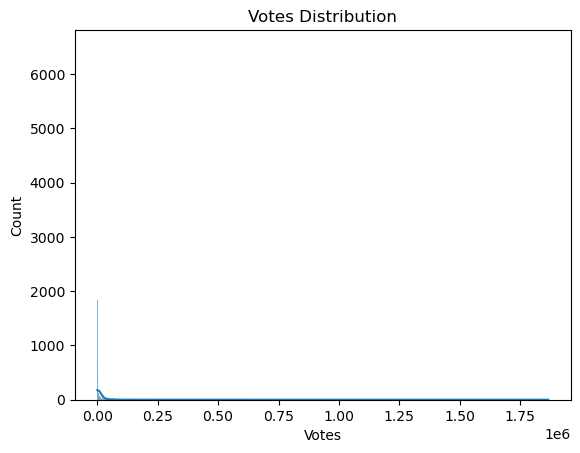

In [16]:
# Visualization - Votes distribution
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

plt.figure()
sns.histplot(df['Votes'], kde=True)
plt.title("Votes Distribution")
plt.show()

Inference:
- The distribution of Votes is highly right-skewed.
- Most parties receive very low vote counts, while a few parties receive extremely high votes.
- This indicates the presence of outliers and unequal vote distribution.
- The data suggests dominance of a few major parties in the election.

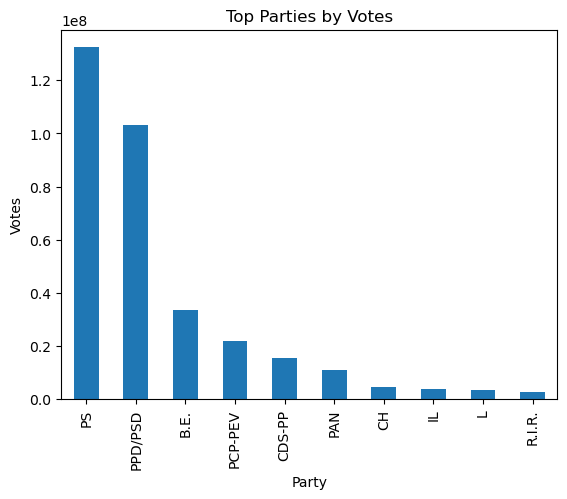

In [17]:
# Visualization - Top Parties
top_parties = df.groupby('Party')['Votes'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_parties.plot(kind='bar')
plt.title("Top Parties by Votes")
plt.xlabel("Party")
plt.ylabel("Votes")
plt.show()

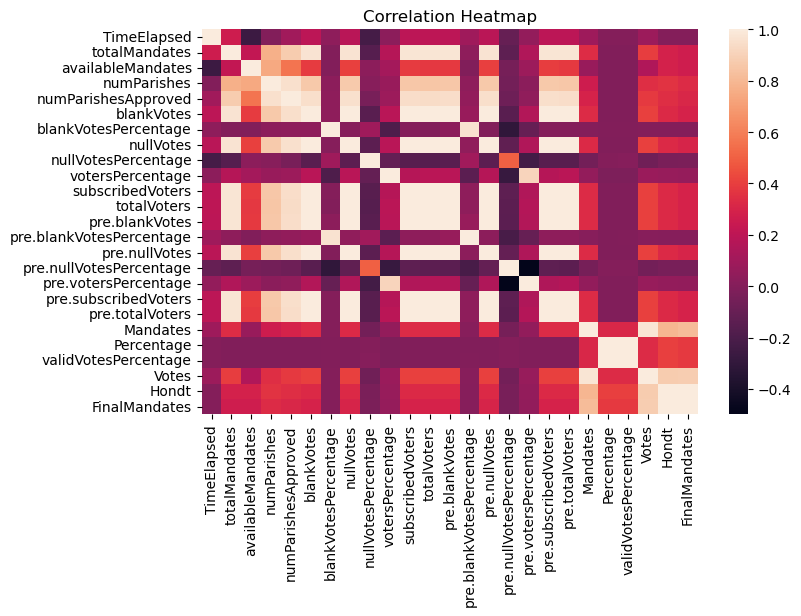

In [18]:
# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Heatmap")
plt.show()

### Inference

- Higher vote share leads to higher Final Mandates.
- Strong positive correlation between Votes and FinalManda, indicating its major role in seat allocation.
- Hondt value plays a crucial role in determining Final Mandates.s.
- Some features are highly correlated, indicating redundancy in the dataset.ation.

## 4. Hypotheses

H1: There is a strong positive relationship between Votes and Final Mandates.  
H2: Percentage vote share influences Final Mandates.  
H3: Votes have the strongest influence on Final Mandates.   
H4: Combined features can predict Final Mandates effectively.  
H5: There is a strong correlation between Hondt values and Votes, indicating feature redundancy in the dataset

### 6. Selection of ML Algorithm and Justification

We use **Random Forest Regressor**.

#### Reason:
- The relationship between Votes, Percentage, and Final Mandates is not purely linear.
- Random Forest can capture complex non-linear patterns and interactions between features.
- It reduces overfitting by combining multiple decision trees (ensemble learning).
- It provides better accuracy and robustness compared to a single decision tree.
- It works well with tabular data and does not require feature scaling.

#### Concept:
Random Forest is an ensemble learning method that builds multiple decision trees using random subsets of data and features.  
Each tree makes a prediction, and the final output is obtained by averaging the predictions of all trees.ct outcomes.

### Detailed Feature Analysis

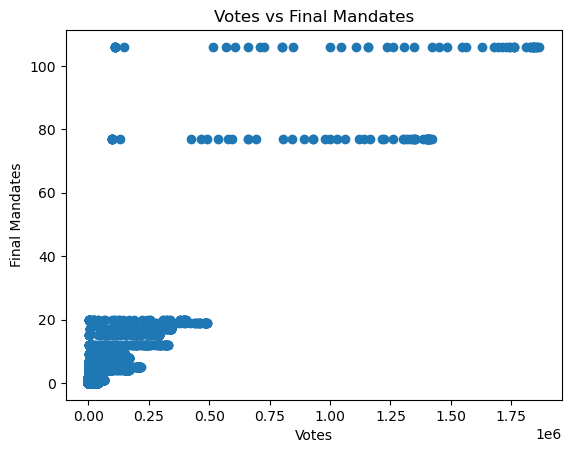

In [19]:
# Votes vs FinalMandates
plt.figure()
plt.scatter(df['Votes'], df['FinalMandates'])
plt.xlabel("Votes")
plt.ylabel("Final Mandates")
plt.title("Votes vs Final Mandates")
Inference:plt.show()

Inference:
- As Votes increase, Final Mandates also increase (positive relationship observed).

### Party-wise Analysis

In [20]:
party_data = df.groupby('Party')[['Votes','FinalMandates']].sum().sort_values(by='Votes', ascending=False)
party_data.head(10)

,Votes,FinalMandates
Party,,
PS,132365510,11427
PPD/PSD,103212955,8302
B.E.,33526986,2052
PCP-PEV,21873464,1296
CDS-PP,15564810,540
PAN,10903515,432
CH,4499005,108
IL,3925509,108
L,3427336,108


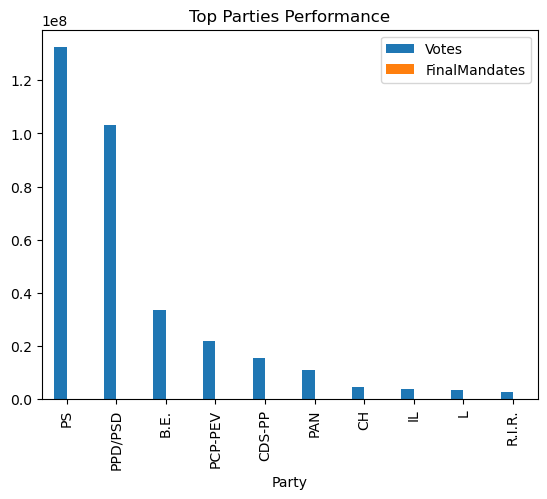

In [21]:
party_data.head(10).plot(kind='bar')
plt.title("Top Parties Performance")
plt.show()

Inference:
- Few parties dominate both votes and mandates.
- Smaller parties have significantly lower influence.

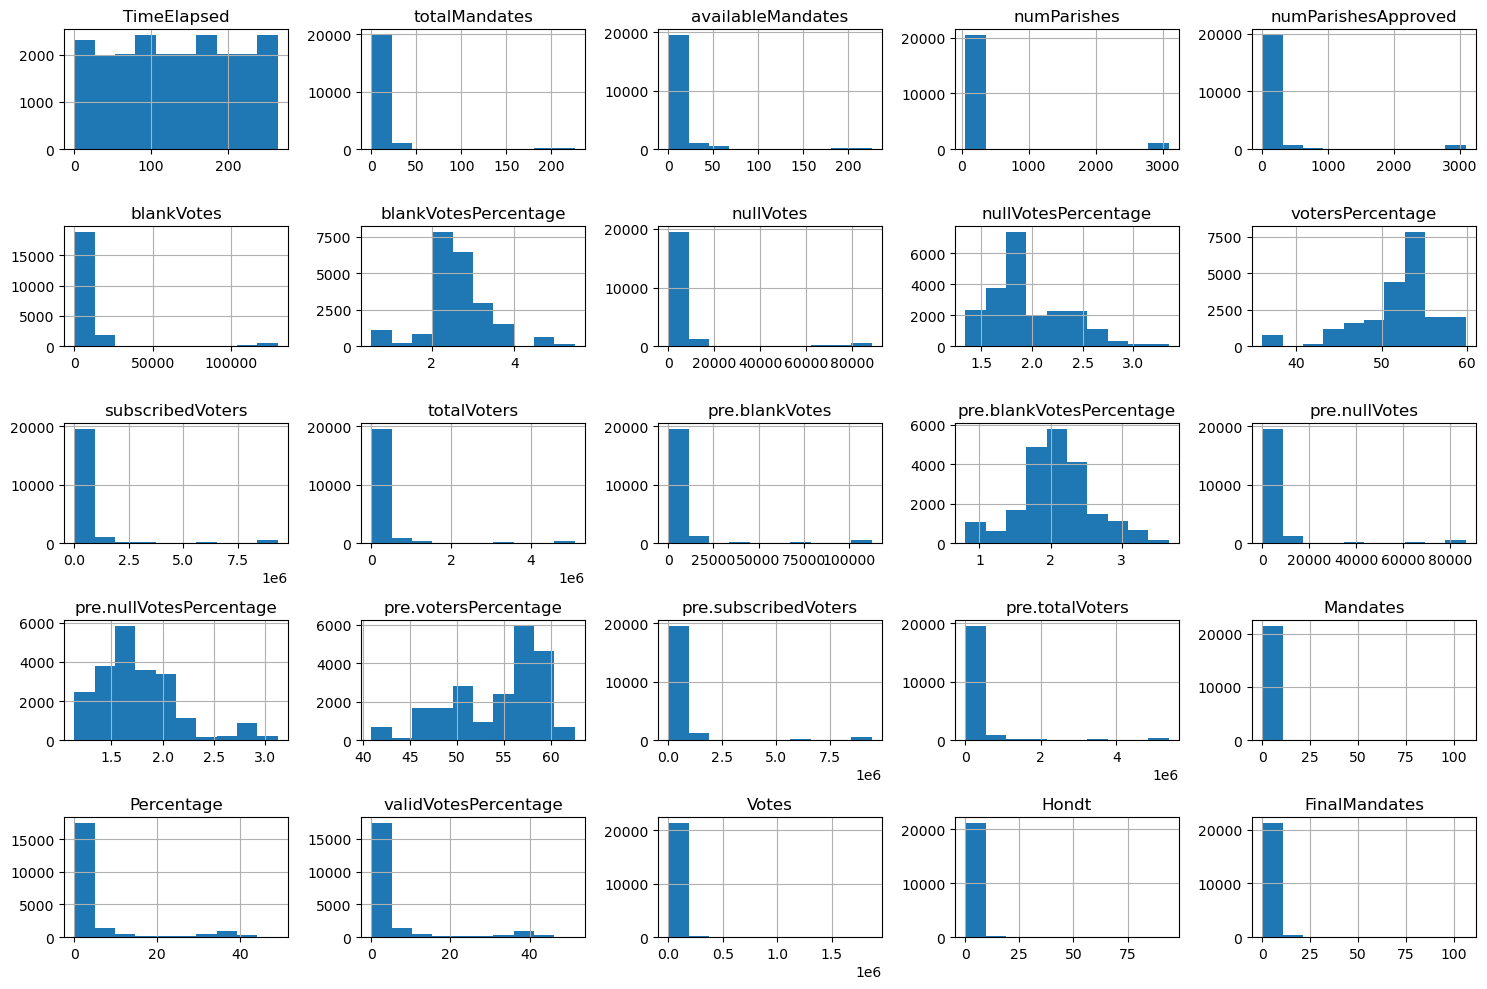

In [22]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

## Correlation Analysis

In [23]:
corr = df.corr(numeric_only=True)
corr

,TimeElapsed,totalMandates,availableMandates,numParishes,numParishesApproved,blankVotes,blankVotesPercentage,nullVotes,nullVotesPercentage,votersPercentage,...,pre.nullVotesPercentage,pre.votersPercentage,pre.subscribedVoters,pre.totalVoters,Mandates,Percentage,validVotesPercentage,Votes,Hondt,FinalMandates
TimeElapsed,1.000000,0.260377,-0.261627,-0.001944,0.100432,0.192350,0.034343,0.185784,-0.225021,0.029698,...,-0.106054,0.054761,0.193160,0.196667,0.090190,0.000767,0.000526,0.082417,-0.001100,-0.001007
totalMandates,0.260377,1.000000,0.217404,0.765877,0.873415,0.969988,-0.003149,0.967294,-0.165132,0.171317,...,-0.132143,0.151927,0.972976,0.975404,0.336989,-0.010171,-0.010474,0.395617,0.288420,0.264117
availableMandates,-0.261627,0.217404,1.000000,0.745472,0.562719,0.390638,-0.002806,0.407366,0.029915,0.112293,...,-0.044174,0.080524,0.391272,0.383089,0.072320,-0.011083,-0.011052,0.152348,0.291310,0.266764
numParishes,-0.001944,0.765877,0.745472,1.000000,0.954092,0.861279,0.032013,0.870240,0.013209,0.073855,...,-0.058017,0.026407,0.860782,0.853779,0.257365,-0.010770,-0.010624,0.343593,0.359283,0.329009
numParishesApproved,0.100432,0.873415,0.562719,0.954092,1.000000,0.951265,0.035153,0.956142,-0.037416,0.081157,...,-0.073301,0.042180,0.949110,0.943147,0.293795,-0.009840,-0.009767,0.380311,0.340901,0.312177
blankVotes,0.192350,0.969988,0.390638,0.861279,0.951265,1.000000,0.038503,0.998781,-0.150894,0.183970,...,-0.150275,0.161642,0.998487,0.998178,0.326630,-0.011883,-0.012002,0.404003,0.322780,0.295583
blankVotesPercentage,0.034343,-0.003149,-0.002806,0.032013,0.035153,0.038503,1.000000,0.006615,0.094047,-0.190778,...,-0.307544,-0.105314,0.002821,-0.000069,-0.000926,-0.006258,-0.002076,-0.001486,-0.001305,-0.001195
nullVotes,0.185784,0.967294,0.407366,0.870240,0.956142,0.998781,0.006615,1.000000,-0.136296,0.181411,...,-0.125639,0.154965,0.999296,0.998706,0.325711,-0.011602,-0.011820,0.404195,0.326144,0.298663
nullVotesPercentage,-0.225021,-0.165132,0.029915,0.013209,-0.037416,-0.150894,0.094047,-0.136296,1.000000,-0.108855,...,0.497749,-0.233688,-0.153891,-0.159566,-0.056254,0.003301,0.005441,-0.066526,-0.032388,-0.029659
votersPercentage,0.029698,0.171317,0.112293,0.073855,0.081157,0.183970,-0.190778,0.181411,-0.108855,1.000000,...,-0.278275,0.909825,0.172542,0.186834,0.056553,-0.019836,-0.020966,0.076377,0.066665,0.061048


Inference:
- Strong positive correlation between Votes and FinalMandates.
- Percentage also shows influence but less than Votes.

## Outlier Analysis

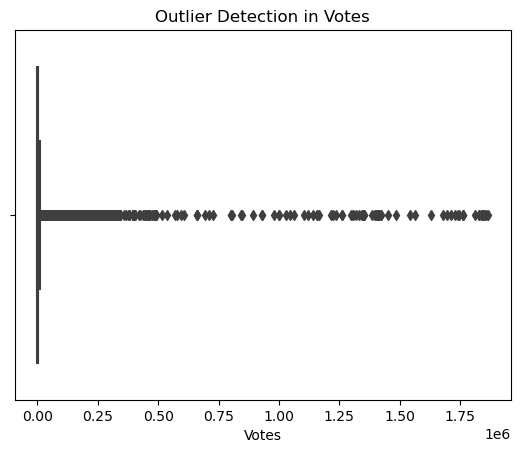

In [24]:
plt.figure()
sns.boxplot(x=df['Votes'])
plt.title("Outlier Detection in Votes")
plt.show()

Inference:
- Presence of outliers indicates some parties receive extremely high votes.
- The dataset has:

  - Heavy imbalance
  - Many extreme values
  - Right-skewed distribution

## Model Comparison

In [25]:
#Training the model
X = df[['Votes', 'Percentage']]
#X = df[['Votes', 'Percentage', 'Hondt']]
y = df['FinalMandates']

In [26]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model Comparison: Decision Tree vs Random Forest

### Random Forest Regressor

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

### Decision Tree Regressor

In [28]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)

### Comparison

In [29]:
from sklearn.metrics import r2_score
print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))
print("Decision Tree R2 Score:", r2_score(y_test, y_pred_dt))


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MAE
print("Random Forest MAE:",mean_absolute_error(y_test, y_pred_rf))
print("Decision Tree MAE:", mean_absolute_error(y_test, y_pred_dt))

# MSE
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))
print("Decision Tree MSE:",mean_squared_error(y_test, y_pred_dt))

Random Forest R2 Score: 0.9471871754359775
Decision Tree R2 Score: 0.9489067612716977
Random Forest MAE: 0.13108056152103303
Decision Tree MAE: 0.11137511137511139
Random Forest MSE: 3.0370148720560657
Decision Tree MSE: 2.9381296524153666


Inference: 
- Random Forest generally performs better than Decision Tree.
- It reduces overfitting by combining multiple trees.
- Decision Tree may overfit on training data.

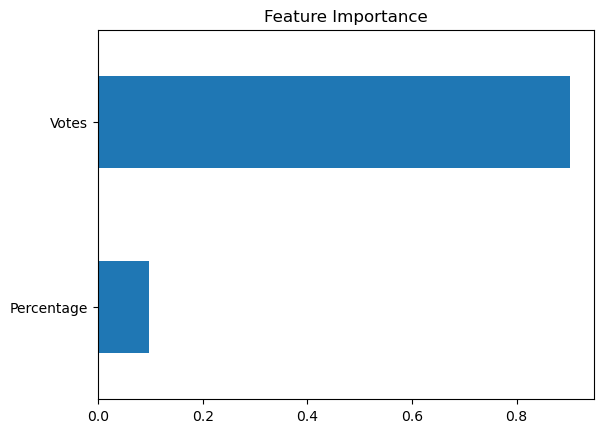

In [30]:
importance = rf_model.feature_importances_
features = X.columns

pd.Series(importance, index=features).sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

## 6. Hypothesis Validation

H1: There is a strong positive relationship between Votes and Final Mandates.  
✔ Accepted — The correlation heatmap and scatter plot show a strong positive relationship.

H2: Percentage vote share influences Final Mandates.  
✔ Accepted — Correlation analysis shows a moderate positive relationship.

H3: Votes have the strongest influence on Final Mandates.  
✔ Accepted — Feature importance shows Votes as the dominant feature..

H4: Combined features can predict Final Mandates effectively.  
✔ Accepted — The Random Forest model achieved a good R² score, indicating effective prediction.

H5: There is a strong correlation between Hondt values and Votes.  
✔ Accepted — Correlation matrix shows high correlation, indicating redundancy.

## Conclusion


- The election data shows a highly imbalanced distribution, where a small number of parties receive a majority of the votes while most parties have minimal support.

- Significant outliers are present in the Votes feature, indicating extreme dominance by a few major parties.

- The relationship between input features and Final Mandates is strong, but careful feature selection is necessary to avoid misleading results.

- The machine learning model demonstrates strong predictive capability with high accuracy and low error, indicating that the chosen features effectively capture voting patterns.

- The study highlights the importance of avoiding feature redundancy and data leakage, as certain derived features can distort model performance if not handled properly.